In [1]:
import numpy as np
import tensorflow as tf
from keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [2]:
model = tf.keras.models.load_model('trained_model.keras')

In [3]:
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_18 (Conv2D)          (None, 128, 128, 32)      896       
                                                                 
 conv2d_19 (Conv2D)          (None, 126, 126, 32)      9248      
                                                                 
 max_pooling2d_8 (MaxPooling  (None, 63, 63, 32)       0         
 2D)                                                             
                                                                 
 conv2d_20 (Conv2D)          (None, 63, 63, 64)        18496     
                                                                 
 conv2d_21 (Conv2D)          (None, 61, 61, 64)        36928     
                                                                 
 max_pooling2d_9 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                  

Visualization single image of test set

In [4]:
%pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


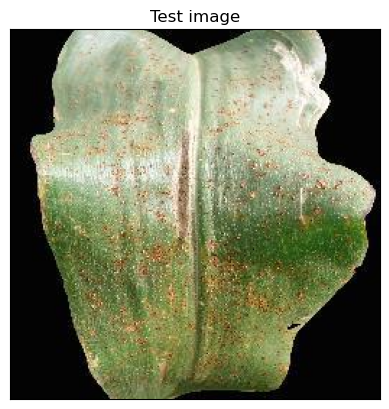

In [19]:
import cv2
image_path = 'test/CornCommonRust2.JPG'
#READ THE IMAGE
img = cv2.imread(image_path)
#convert the image from BGR to RGB
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

#display the image
plt.imshow(img)
plt.title("Test image")
plt.xticks([])
plt.yticks([])
plt.show()

# Testing Model

In [20]:
image = tf.keras.preprocessing.image.load_img(image_path,target_size=(128,128))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
#convert single image to a batch
input_arr = np.array([input_arr])
print(input_arr.shape)

(1, 128, 128, 3)


In [21]:
prediction = model.predict(input_arr)
prediction,prediction.shape

1/1 [==============================] - 0s 31ms/step


(array([[2.23570417e-18, 2.04914521e-22, 1.51616798e-25, 5.28257266e-23,
         1.68235897e-26, 4.35740425e-18, 1.12754524e-26, 1.78292389e-15,
         1.00000000e+00, 2.95583496e-17, 4.06552912e-19, 5.66266323e-30,
         5.19293723e-25, 2.02808878e-27, 2.78836649e-29, 1.77552647e-22,
         7.10396565e-19, 5.43377774e-30, 4.50322952e-23, 2.21183724e-22,
         1.07015439e-14, 3.26091161e-30, 1.20215787e-34, 2.98436528e-31,
         5.74760690e-29, 1.77251997e-24, 4.46159139e-24, 2.19371490e-27,
         2.41276440e-27, 2.51380735e-23, 3.79217753e-20, 3.59504330e-23,
         4.13452653e-22, 5.16016366e-30, 6.44281884e-27, 1.22799749e-27,
         1.86601559e-31, 5.00388432e-22]], dtype=float32),
 (1, 38))

In [22]:
result_index = np.argmax(prediction)
result_index

8

In [23]:
class_name = ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']

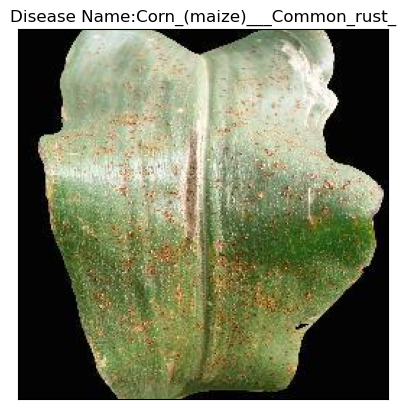

In [24]:
#display  result of disease prediction
model_prediction = class_name[result_index]
plt.imshow(img)
plt.title(f"Disease Name:{model_prediction}")
plt.xticks([])
plt.yticks([])
plt.show()


In [25]:
model_prediction

'Corn_(maize)___Common_rust_'